<a href="https://colab.research.google.com/github/alexb7z/aqua-predict/blob/main/AquaPredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AquaPredict - Sistema inteligente para reservatórios de água

Universidade Federal Rural do Semi-Árido (UFERSA) <br>
Disciplina: Sistemas Inteligentes <br>
Docente: Pedro Thiago Valério de Souza <br>

Autores: <br>
Alex Bruno Duarte | alex.duarte@alunos.ufersa.edu.br | <a href="https://github.com/alexb7z" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Carlos Henrique de Queiroz | carlos.queiroz53447@alunos.ufersa.edu.br | <a href="https://github.com/CarlossQueiroz" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
José Veríssimo de Oliveira Queiroz | jose.queiroz58390@alunos.ufersa.edu.br | <a href="https://github.com/JV-ANUBIS" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Thallys Araújo de Morais | thallys.araujo@alunos.ufersa.edu.br | <a href="https://github.com/ThallysAM" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br> <br>


## 1. Introdução
---

Este trabalho apresenta o AquaPredict, um sistema inteligente desenvolvido como o projeto final da disciplina de Sistemas Inteligentes na Universidade Federal Rural do Semi-Árido (UFERSA), sob a docência do professor Dr. Pedro Thiago Valério de Souza. O projeto surge para solucionar as limitações dos sistemas tradicionais de automação de reservatórios, que atuam de forma puramente reativa e geram ineficiências energéticas e operacionais. Integrando conceitos de Internet das Coisas (IoT) e Aprendizado de Máquina, o AquaPredict utiliza uma Rede Neural Artificial do tipo Multi-Layer Perceptron (MLP) para transformar o controle de bombas hidráulicas em uma operação preditiva e proativa, antecipando o comportamento e a demanda hídrica.

### 1.1. Objetivo principal
---

Implementar e avaliar a rede neural MLP do AquaPredict, capacitando o sistema a prever o nível do reservatório hídrico com uma hora de antecedência para viabilizar a transição de um controle reativo para proativo.

### 1.2. Objetivos especificos
---

- Engenharia de Dados: Aplicar feature engineering em séries temporais de alta granularidade (15 minutos) para extrair sazonalidades e criar variáveis de memória histórica (lags).
- Modelagem Preditiva: Treinar e otimizar a arquitetura da rede neural Multi-Layer Perceptron (MLP) focada no comportamento e na dinâmica de consumo hídrico.
- Validação Científica: Desenvolver um modelo de Regressão Linear Múltipla para atuar como linha de base (baseline), permitindo uma comparação rigorosa do ganho de desempenho da Inteligência Artificial.
- Avaliação de Desempenho: Comprovar a confiabilidade do algoritmo através das métricas $R^2$, MAE e RMSE, atestando a segurança necessária para o acionamento automatizado e preventivo de bombas físicas.

## 2. Conjunto de dados
---

Para o desenvolvimento desta etapa do trabalho, foi utilizado o conjunto de dados "SOWEKI Water Demand Dataset", disponibilizado publicamente no repositório Zenodo pelos pesquisadores Felix Sehmer, Maximilian Hoffmann, Norberth Kloos e Ralph Bergmann (publicado em abril de 2026).

Diferente do conjunto anterior, este dataset contém medições contínuas com uma granularidade mais alta, registrando a demanda e os níveis hídricos em intervalos de 15 minutos. O objetivo principal da utilização desta base é permitir o desenvolvimento de modelos preditivos de curtíssimo prazo, capazes de antecipar quedas de nível e auxiliar no acionamento imediato e inteligente da operação de bombas em reservatórios.

Neste projeto foi utilizado o arquivo "soweki_wdd_1.csv", estruturado em formato de série temporal. Para que a Rede Neural pudesse aprender o comportamento do sistema, os dados brutos passaram por uma engenharia de features.

As principais variáveis presentes e construídas no modelo são:

- **timestamp**: data e horário exato da observação, da qual foram extraídas as sazonalidades (Hora, Minuto e Dia da Semana);

- **value**: valor contínuo registrado para a demanda/nível de água no respectivo intervalo de 15 minutos;

- **Lags (Lag1 a Lag4)**: variáveis de histórico (memória) criadas no pré-processamento. Elas representam as últimas quatro leituras do sensor, permitindo que o modelo compreenda o comportamento da água na última 1 hora;

- **Target**: a variável alvo do modelo, configurada para prever o estado do sistema 1 hora à frente (4 intervalos no futuro).

## 3. Pré-processamento
---

Importação das bibliotecas

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregamento dos dados

In [34]:
# URL do dataset bruto no repositório
url = "https://raw.githubusercontent.com/alexb7z/aqua-predict/main/data/soweki_wdd_1.csv"

# Carrega os dados em um DataFrame do Pandas
df = pd.read_csv(url)

# Exibe as 5 primeiras linhas para conferência rápida
df.head()

,timestamp,value
0,2024-09-06T22:00:00+00:00,2.911446
1,2024-09-06T22:15:00+00:00,2.764983
2,2024-09-06T22:30:00+00:00,2.903234
3,2024-09-06T22:45:00+00:00,2.134375
4,2024-09-06T23:00:00+00:00,1.929706


Pré-precssamento dos dados

In [35]:
# Converte a coluna de timestamp (string) para o tipo datetime do Pandas
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extrai features temporais para o modelo entender a sazonalidade diária e em minutos
df["Hour"] = df["timestamp"].dt.hour
df["Minute"] = df["timestamp"].dt.minute
df["DayOfWeek"] = df["timestamp"].dt.dayofweek

# Cria as features de atraso (Lags): leituras anteriores em intervalos de 15 minutos
df["Lag1"] = df["value"].shift(1)   # 15 min atrás
df["Lag2"] = df["value"].shift(2)   # 30 min atrás
df["Lag3"] = df["value"].shift(3)   # 45 min atrás
df["Lag4"] = df["value"].shift(4)   # 60 min atrás

# Cria a variável alvo (Target): O valor que queremos prever daqui a 1 hora (4 passos de 15 min)
df["Target"] = df["value"].shift(-4)

# Remove as linhas com valores nulos gerados pelos comandos 'shift'
df = df.dropna()

# Filtra e reordena o DataFrame para manter apenas as colunas úteis para o modelo
df = df[
    [
        "Hour",
        "Minute",
        "DayOfWeek",
        "Lag1",
        "Lag2",
        "Lag3",
        "Lag4",
        "Target"
    ]
]

# Exibe o dataset pronto para a modelagem
df.head()

,Hour,Minute,DayOfWeek,Lag1,Lag2,Lag3,Lag4,Target
4,23,0,4,2.134375,2.903234,2.764983,2.911446,2.032708
5,23,15,4,1.929706,2.134375,2.903234,2.764983,1.749732
6,23,30,4,1.757241,1.929706,2.134375,2.903234,1.877401
7,23,45,4,1.957656,1.757241,1.929706,2.134375,1.640061
8,0,0,5,1.814308,1.957656,1.757241,1.929706,1.371196


Definição das features e target

In [36]:
# X contém apenas as variáveis preditivas (recursos temporais e lags históricos)
X = df[
    [
        "Hour",
        "Minute",
        "DayOfWeek",
        "Lag1",
        "Lag2",
        "Lag3",
        "Lag4"
    ]
]

# y contém a variável que queremos prever (o valor futuro)
y = df["Target"]

Padronização dos dados

In [37]:
# Inicializa o padronizador (remove a média e escala para variância unitária)
scaler = StandardScaler()

# Ajusta o scaler aos dados e já transforma o conjunto X
X_scaled = scaler.fit_transform(X)

Divisão treino/teste

In [38]:
# Separa 80% dos dados para treinar o modelo e 20% para testar.
# shuffle=False é FUNDAMENTAL aqui porque são dados temporais.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    shuffle=False
)

## 4. Implementação da MLP
---

In [39]:
# Instancia o Regressor Multi-Layer Perceptron (Rede Neural para valores contínuos)
mlp = MLPRegressor(
    # Define a arquitetura da rede: duas camadas ocultas, com 64 e 32 neurônios
    hidden_layer_sizes=(64, 32),

    # Função de ativação ReLU para capturar padrões não-lineares
    activation="relu",

    # Número máximo de iterações configurado para 1000 para garantir a convergência neste dataset
    max_iter=1000,

    # Define uma semente aleatória para garantir a reprodutibilidade
    random_state=42
)

# Treina o modelo usando os dados de treino (features X e gabarito y)
mlp.fit(X_train, y_train)

# Previsão com dados de teste
# Usa o modelo treinado para prever os valores futuros com base nos dados de teste
y_pred = mlp.predict(X_test)

## 5. Implementação da Regressão Linear
---

In [40]:
# Instancia o modelo de Regressão Linear (Modelo Baseline)
lr = LinearRegression()

# Treina o modelo com os dados de treino
lr.fit(X_train, y_train)

# Realiza as previsões com os dados de teste (já no mesmo bloco para agilizar)
y_pred_lr = lr.predict(X_test)

## 6. Avaliação do modelo
---

Métricas do MLP

In [41]:
# MAE (Mean Absolute Error): Erro médio absoluto. Mostra o desvio médio das previsões.
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error): Raiz do erro quadrático médio. Penaliza mais fortemente os erros grandes.
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# R² (R-Squared): Coeficiente de determinação. Mostra a qualidade do ajuste do modelo.
r2 = r2_score(y_test, y_pred)

print("--- Métricas do MLP ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

--- Métricas do MLP ---
MAE:  0.84
RMSE: 1.11
R²:   0.7880


Gráficos de consumo real x consumo previsto do MLP

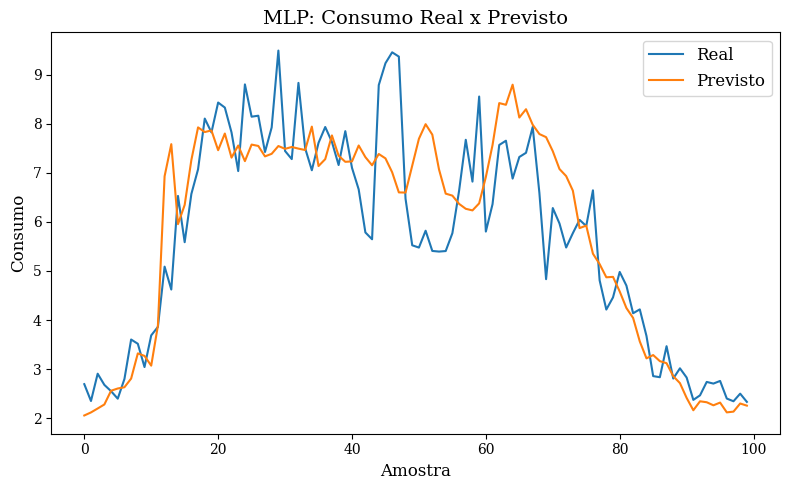

In [42]:
# Fontes IEEE
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif", "Times New Roman", "serif"]

# Proporção retangular (8x5)
plt.figure(figsize=(8, 5))

# Plota as primeiras 100 amostras
plt.plot(y_test.values[:100], label="Real", linewidth=1.5)
plt.plot(y_pred[:100], label="Previsto", linewidth=1.5)

# Textos e legendas com tamanho ajustado para leitura no PDF
plt.title("MLP: Consumo Real x Previsto", fontsize=14)
plt.xlabel("Amostra", fontsize=12)
plt.ylabel("Consumo", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)

# Remove as bordas brancas sobressalentes
plt.tight_layout()

# Salva em alta resolução (300 DPI) para o artigo
plt.savefig('fig1.png', dpi=300)

plt.show()

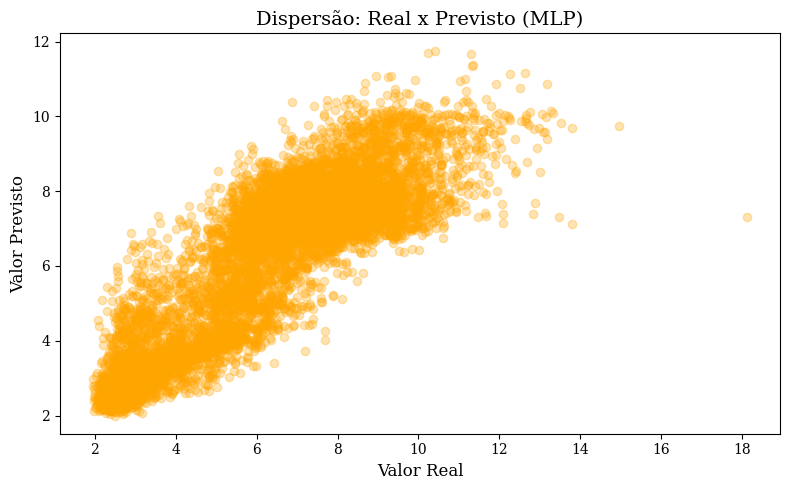

In [43]:
# Mesma proporção retangular exata do primeiro gráfico (8x5) para simetria no artigo
plt.figure(figsize=(8, 5))

# Gráfico de Dispersão com transparência (alpha) para ver a densidade dos acertos
plt.scatter(y_test, y_pred, alpha=0.3, color="orange")

# Textos e legendas
plt.title("Dispersão: Real x Previsto (MLP)", fontsize=14)
plt.xlabel("Valor Real", fontsize=12)
plt.ylabel("Valor Previsto", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Remove as bordas brancas
plt.tight_layout()

# Salva em alta resolução (300 DPI) para o artigo
plt.savefig('fig2.png', dpi=300)

plt.show()

Métricas da Regressão Linear

In [44]:
# Calcula as métricas para o modelo de Regressão Linear
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Métricas da Regressão Linear (Baseline) ---")
print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²:   {r2_lr:.4f}")

--- Métricas da Regressão Linear (Baseline) ---
MAE:  1.15
RMSE: 1.45
R²:   0.6394


Gráficos de consumo real x consumo previsto da Regressão Linear

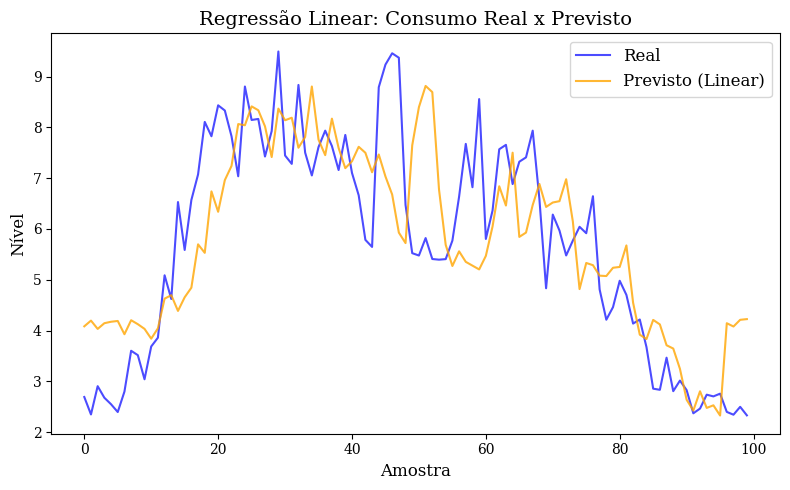

In [45]:
# Proporção retangular (8x5) igual ao do MLP
plt.figure(figsize=(8, 5))

# Plota as primeiras 100 amostras (mesma janela de tempo do MLP)
# Mantive as suas cores e transparências (alpha), mas adicionei a espessura da linha (linewidth)
plt.plot(y_test.values[:100], label="Real", color="blue", alpha=0.7, linewidth=1.5)
plt.plot(y_pred_lr[:100], label="Previsto (Linear)", color="orange", alpha=0.8, linewidth=1.5)

# Textos e legendas com tamanho ajustado
plt.title("Regressão Linear: Consumo Real x Previsto", fontsize=14)
plt.xlabel("Amostra", fontsize=12)
plt.ylabel("Nível", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)

# Remove as bordas brancas
plt.tight_layout()

# Salva em alta resolução (300 DPI) com um nome diferente para não apagar o gráfico do MLP
plt.savefig('fig_lr.png', dpi=300)

plt.show()

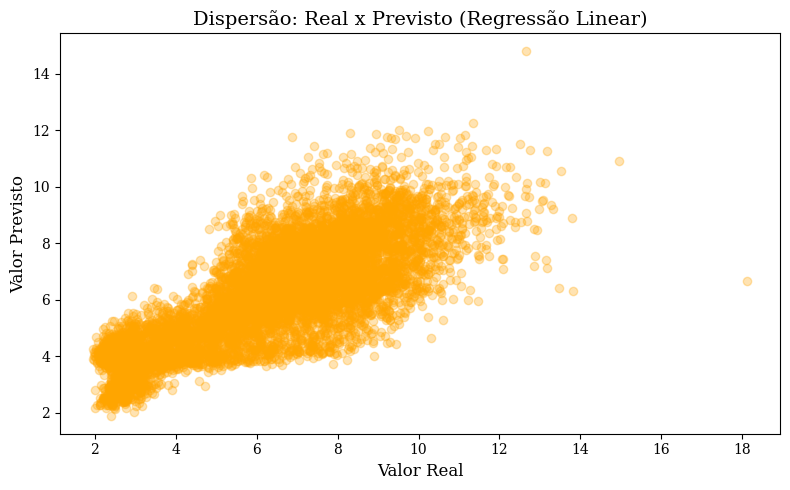

In [46]:
# Mesma proporção retangular (8x5) que definimos para os outros gráficos
plt.figure(figsize=(8, 5))

# Plota a dispersão usando as previsões da Regressão Linear
plt.scatter(y_test, y_pred_lr, alpha=0.3, color="orange")

# Textos com tamanho ajustado para leitura no PDF
plt.title("Dispersão: Real x Previsto (Regressão Linear)", fontsize=14)
plt.xlabel("Valor Real", fontsize=12)
plt.ylabel("Valor Previsto", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Remove as bordas brancas sobressalentes
plt.tight_layout()

# Salva em alta resolução (300 DPI) com um nome específico
plt.savefig('fig_lr_scatter.png', dpi=300)

plt.show()

## 7. Conclusão
---

A avaliação das métricas evidencia a clara superioridade da abordagem não-linear para a antecipação do nível hídrico. Ao atingir um coeficiente de determinação ($R^2$) de 0.7880, o modelo Multi-Layer Perceptron (MLP) demonstrou uma capacidade significativamente maior de mapear a variância do sistema em comparação ao baseline de Regressão Linear ($R^2$ = 0.6394).

A precisão do algoritmo é atestada pelo Erro Médio Absoluto (MAE) de 0.84 (contra 1.15 do modelo linear) e pelo RMSE de 1.11, indicando que as previsões desviam minimamente das leituras reais dos sensores. A estratégia de engenharia de atributos, fundamentada na utilização de quatro janelas de atraso temporal (lags equivalentes a uma hora de histórico), provou-se determinante para o modelo assimilar a dinâmica de vazão no curto prazo.

Sob a ótica operacional, essa margem de erro sub-unitária confere a robustez necessária para embarcar a lógica de controle. A consistência preditiva alcançada garante que o acionamento físico do relé do sistema ocorra de forma segura e preventiva, mitigando falhas na automação e otimizando a eficiência operacional da infraestrutura de bombeamento.